# 🩺 Diabetes Prediction Using Machine Learning


**Dataset: Pima Indians Diabetes Dataset — UCI Machine Learning Repository**

📥 **Dataset Link:** https://archive.ics.uci.edu/dataset/34/diabetes

---
### What are we doing?
We want to **predict whether a person has diabetes or not** using health data like glucose, BMI, age etc.
- **0 = Not Diabetic**
- **1 = Diabetic**

This is a **binary classification** problem.

## 📦 Cell 1: Import All Libraries
First, we import all the tools we need. Think of these as our toolbox!

In [1]:
# Basic tools for math and data
import numpy as np
import pandas as pd

# Tools for drawing graphs/charts
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning tools
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_curve, auc, ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings('ignore')

# Make our plots look nice
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


## 📂 Cell 2: Load the Dataset
We load the diabetes dataset. This dataset has **768 patients** and **9 columns**.

In [2]:
# Load dataset directly from URL (no download needed!)
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv'

# These are the column names for this dataset
columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
           'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

# Load the data into a table called 'df' (dataframe)
df = pd.read_csv(url, names=columns)

print('✅ Dataset loaded!')
print(f'Shape: {df.shape}  →  {df.shape[0]} rows (patients), {df.shape[1]} columns')
print('\nFirst 5 rows:')
df.head()

✅ Dataset loaded!
Shape: (768, 9)  →  768 rows (patients), 9 columns

First 5 rows:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 🔍 Cell 3: Explore the Dataset — Basic Info
Let's understand what our data looks like.

In [3]:
print('=== DATASET INFORMATION ===')
print(df.info())
print('\n=== MISSING VALUES ===')
print(df.isnull().sum())
print('\n=== CLASS DISTRIBUTION ===')
print(df['Outcome'].value_counts())
print('\n0 = Not Diabetic,  1 = Diabetic')

=== DATASET INFORMATION ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None

=== MISSING VALUES ===
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
Dia

## 📊 Cell 4: Visualize Class Distribution
How many diabetic vs non-diabetic patients are in our data?

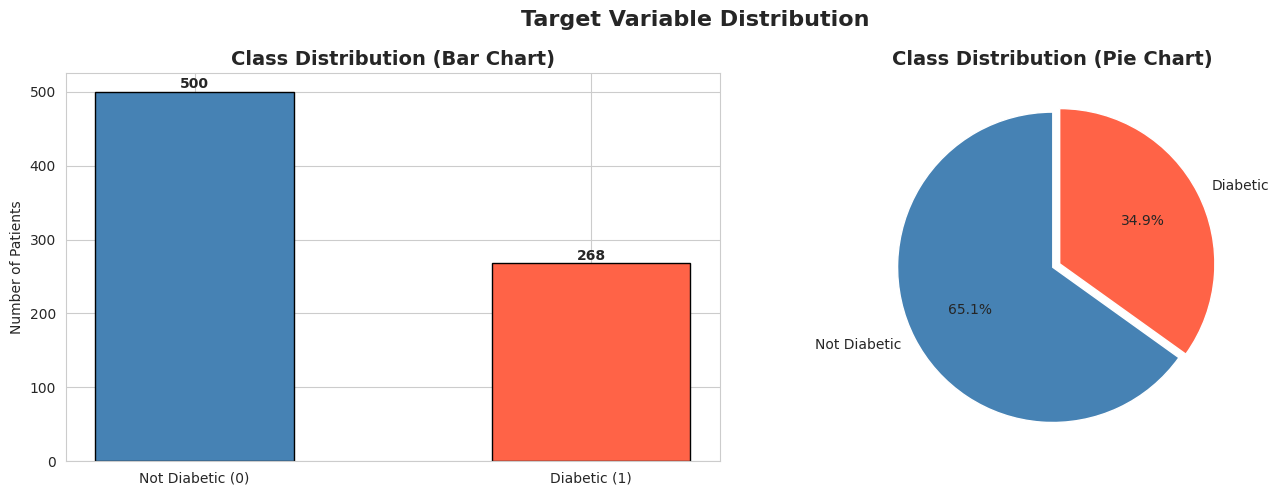

🔎 Observation: Dataset is slightly imbalanced — more non-diabetic patients than diabetic.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
counts = df['Outcome'].value_counts()
axes[0].bar(['Not Diabetic (0)', 'Diabetic (1)'], counts.values,
            color=['steelblue', 'tomato'], edgecolor='black', width=0.5)
axes[0].set_title('Class Distribution (Bar Chart)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Patients')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=['Not Diabetic', 'Diabetic'],
            colors=['steelblue', 'tomato'], autopct='%1.1f%%',
            startangle=90, explode=(0, 0.05))
axes[1].set_title('Class Distribution (Pie Chart)', fontsize=14, fontweight='bold')

plt.suptitle('Target Variable Distribution', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()
print('🔎 Observation: Dataset is slightly imbalanced — more non-diabetic patients than diabetic.')

## 📈 Cell 5: Statistical Summary
Let's see the average, minimum, maximum values for each feature.

In [5]:
print('=== STATISTICAL SUMMARY ===')
df.describe().round(2)

=== STATISTICAL SUMMARY ===


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24,0.35
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00,0.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


## 🔍 Cell 6: Check for Hidden Missing Values (Zeros)
Some columns like Glucose and BMI **cannot be zero** in real life. Zero here means data is missing!

=== ZERO VALUES (actually missing data) ===
Glucose                       :    5 zeros  (0.7%)
BloodPressure                 :   35 zeros  (4.6%)
SkinThickness                 :  227 zeros  (29.6%)
Insulin                       :  374 zeros  (48.7%)
BMI                           :   11 zeros  (1.4%)


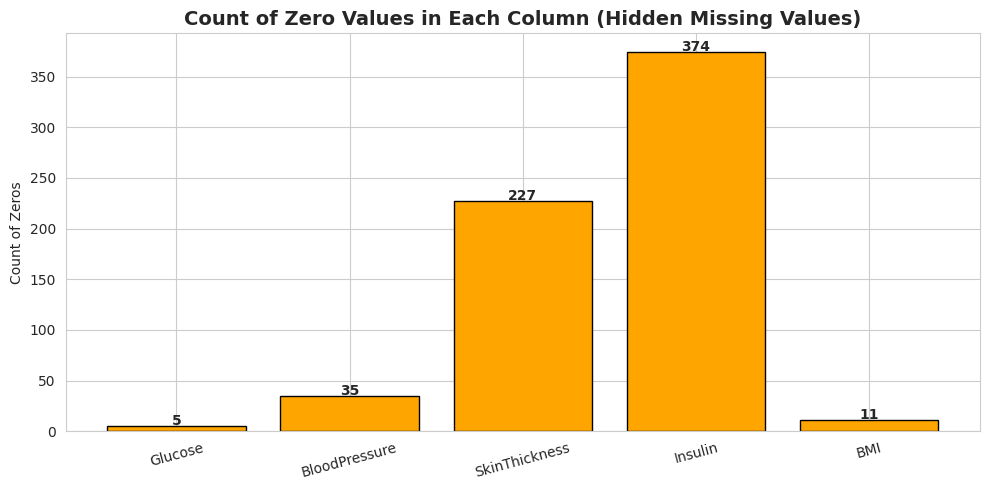

In [6]:
# Columns that should NOT have zeros (medically impossible)
zero_not_allowed = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print('=== ZERO VALUES (actually missing data) ===')
for col in zero_not_allowed:
    count = (df[col] == 0).sum()
    pct = count / len(df) * 100
    print(f'{col:30s}: {count:4d} zeros  ({pct:.1f}%)')

# Visualize zeros
zero_counts = [(df[col] == 0).sum() for col in zero_not_allowed]
plt.figure(figsize=(10, 5))
bars = plt.bar(zero_not_allowed, zero_counts, color='orange', edgecolor='black')
for bar, val in zip(bars, zero_counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             str(val), ha='center', fontweight='bold')
plt.title('Count of Zero Values in Each Column (Hidden Missing Values)', fontsize=14, fontweight='bold')
plt.ylabel('Count of Zeros')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 🧹 Cell 7: Data Preprocessing — Replace Zeros with Median
We replace the impossible zeros with the **median** (middle value) of that column.

In [7]:
# Make a copy so we don't mess up the original
df_clean = df.copy()

# Replace 0 with median for columns that can't be zero
for col in zero_not_allowed:
    median_val = df_clean[col].median()
    df_clean[col] = df_clean[col].replace(0, median_val)
    print(f'✅ {col}: replaced zeros with median = {median_val:.1f}')

print('\n✅ All zeros replaced! Data is now clean.')
print(f'Dataset shape remains: {df_clean.shape}')

✅ Glucose: replaced zeros with median = 117.0
✅ BloodPressure: replaced zeros with median = 72.0
✅ SkinThickness: replaced zeros with median = 23.0
✅ Insulin: replaced zeros with median = 30.5
✅ BMI: replaced zeros with median = 32.0

✅ All zeros replaced! Data is now clean.
Dataset shape remains: (768, 9)


## 🌡️ Cell 8: Distribution of Each Feature
Let's visualize how each feature is distributed for diabetic vs non-diabetic patients.

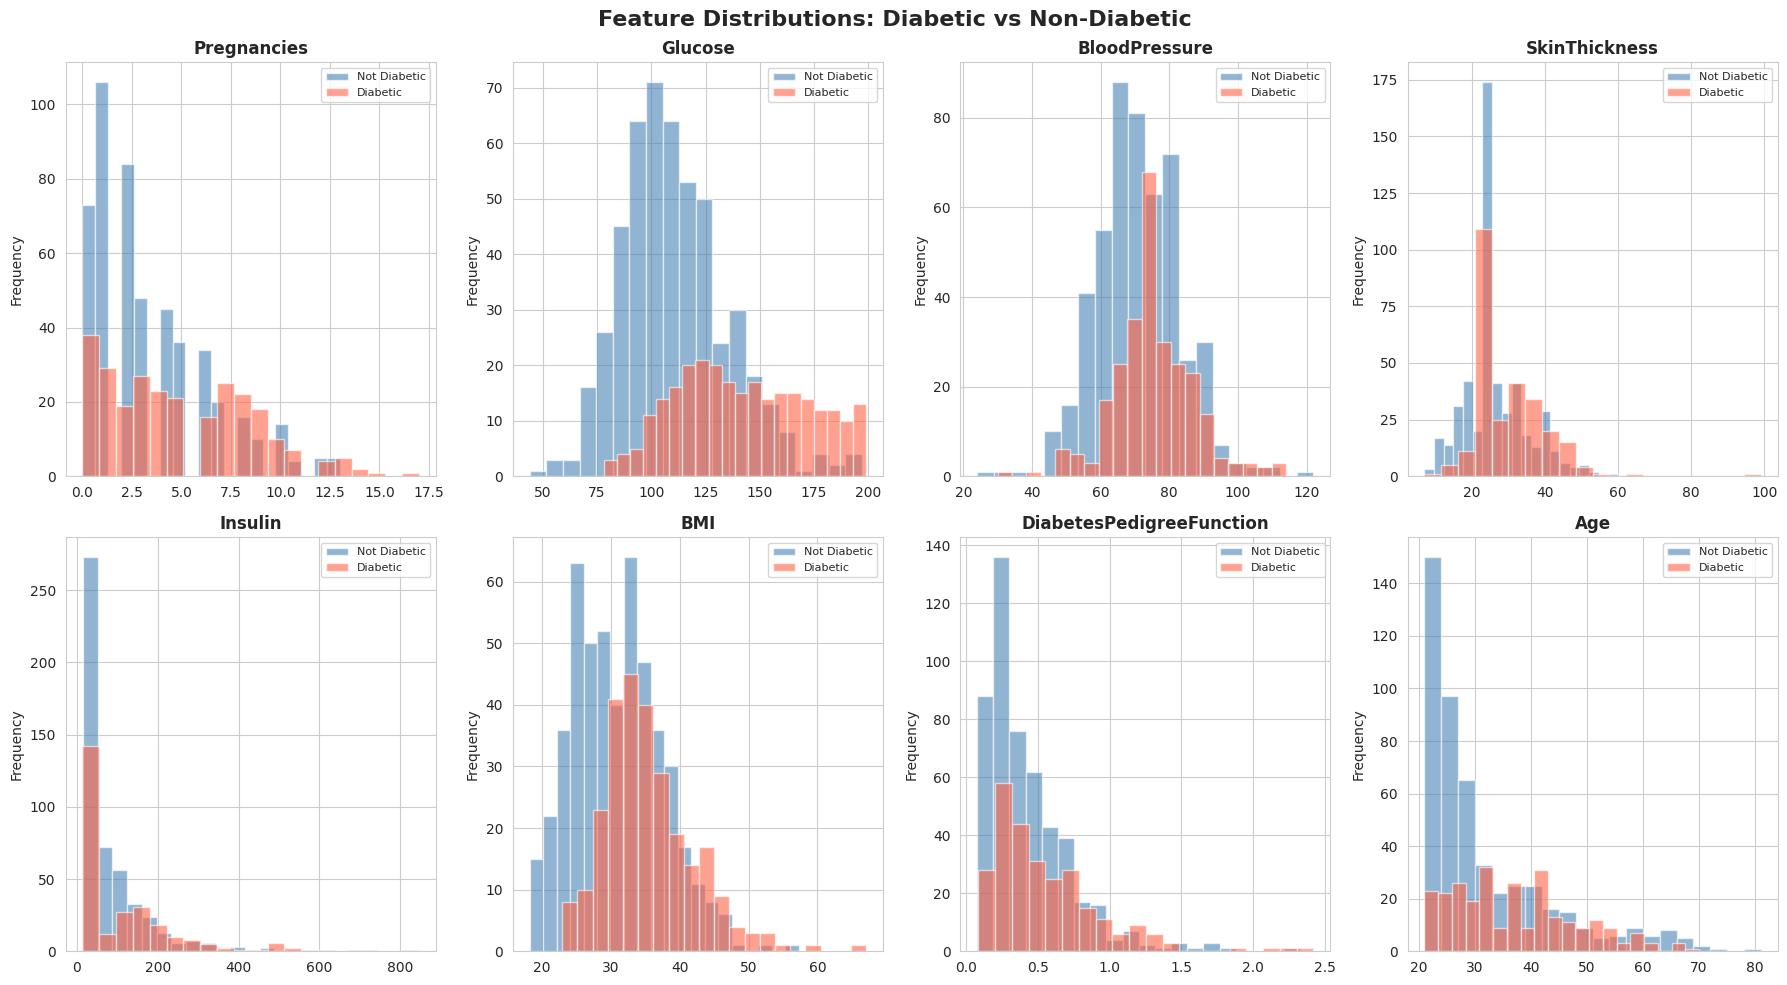

🔎 Key Observation: Glucose and BMI show the biggest difference between the two classes!


In [8]:
features = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
            'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, feature in enumerate(features):
    # Plot for each class separately
    df_clean[df_clean['Outcome'] == 0][feature].plot(
        kind='hist', ax=axes[i], alpha=0.6, color='steelblue',
        label='Not Diabetic', bins=20, edgecolor='white'
    )
    df_clean[df_clean['Outcome'] == 1][feature].plot(
        kind='hist', ax=axes[i], alpha=0.6, color='tomato',
        label='Diabetic', bins=20, edgecolor='white'
    )
    axes[i].set_title(feature, fontsize=12, fontweight='bold')
    axes[i].legend(fontsize=8)
    axes[i].set_xlabel('')

plt.suptitle('Feature Distributions: Diabetic vs Non-Diabetic', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()
print('🔎 Key Observation: Glucose and BMI show the biggest difference between the two classes!')

## 🔗 Cell 9: Correlation Heatmap
Which features are most related to diabetes? A heatmap shows this clearly.

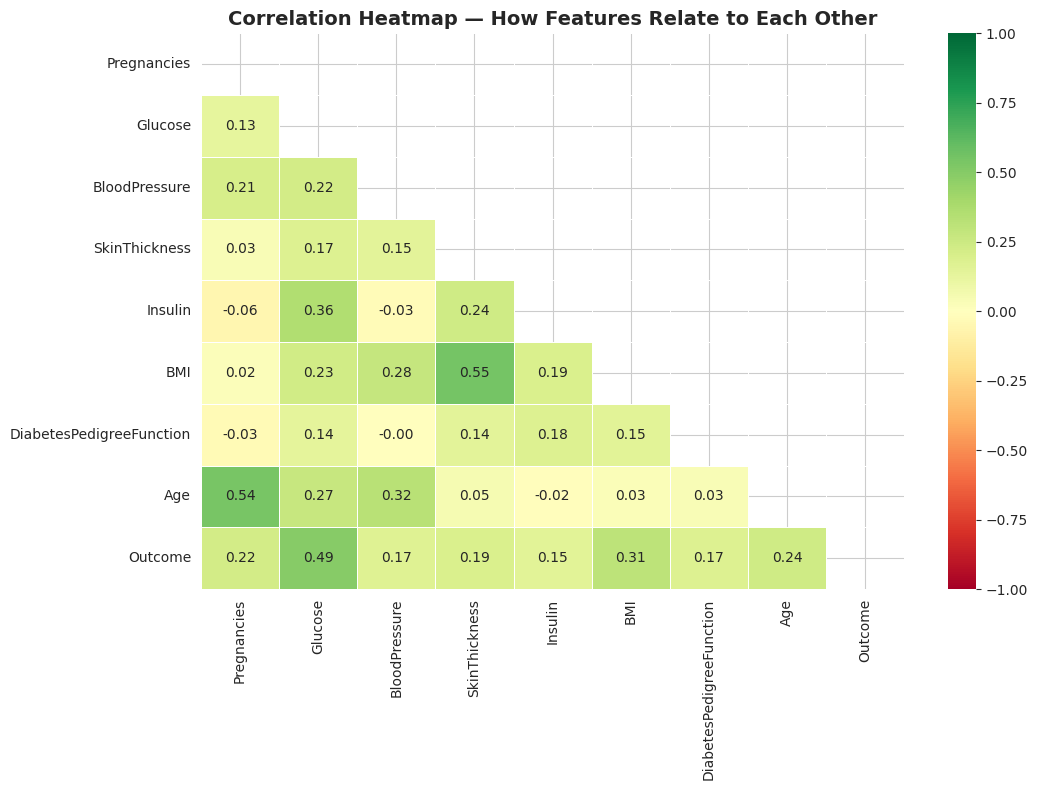

=== Correlation with Outcome (Target) ===
Glucose                     0.493
BMI                         0.312
Age                         0.238
Pregnancies                 0.222
SkinThickness               0.189
DiabetesPedigreeFunction    0.174
BloodPressure               0.166
Insulin                     0.148
Name: Outcome, dtype: float64

🔎 Glucose has the STRONGEST correlation with diabetes!


In [9]:
plt.figure(figsize=(11, 8))
corr_matrix = df_clean.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Show only lower triangle
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, linewidths=0.5, vmin=-1, vmax=1,
            annot_kws={'size': 10})
plt.title('Correlation Heatmap — How Features Relate to Each Other', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Show correlation with target
print('=== Correlation with Outcome (Target) ===')
corr_with_target = corr_matrix['Outcome'].drop('Outcome').sort_values(ascending=False)
print(corr_with_target.round(3))
print('\n🔎 Glucose has the STRONGEST correlation with diabetes!')

## 📊 Cell 10: Seaborn Pairplot
This shows the relationship between all features at once — very useful for exploration!

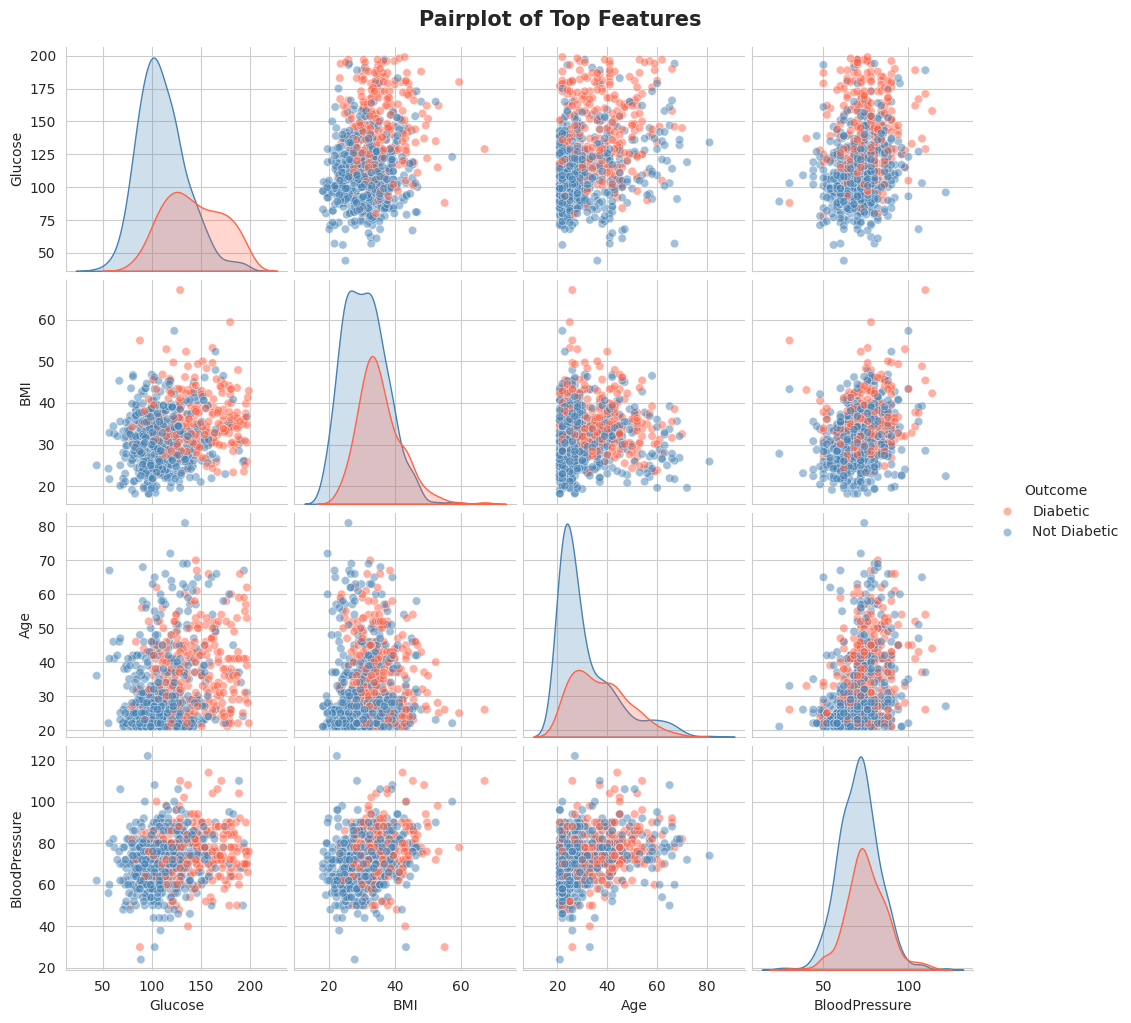

🔎 Glucose vs BMI shows the clearest separation between diabetic and non-diabetic!


In [10]:
# Use top 4 features for cleaner plot
top_features = ['Glucose', 'BMI', 'Age', 'BloodPressure', 'Outcome']

pair_df = df_clean[top_features].copy()
pair_df['Outcome'] = pair_df['Outcome'].map({0: 'Not Diabetic', 1: 'Diabetic'})

g = sns.pairplot(pair_df, hue='Outcome', palette={'Not Diabetic': 'steelblue', 'Diabetic': 'tomato'},
                 diag_kind='kde', plot_kws={'alpha': 0.5})
g.fig.suptitle('Pairplot of Top Features', y=1.02, fontsize=15, fontweight='bold')
plt.show()
print('🔎 Glucose vs BMI shows the clearest separation between diabetic and non-diabetic!')

## ✂️ Cell 11: Split Data — 70% Train / 10% Validation / 20% Test
We split the data into 3 parts as required by our project guidelines.

✅ Data Split Complete!
   Training set  : 537 samples (70%)
   Validation set: 77 samples (10%)
   Test set      : 154 samples (20%)


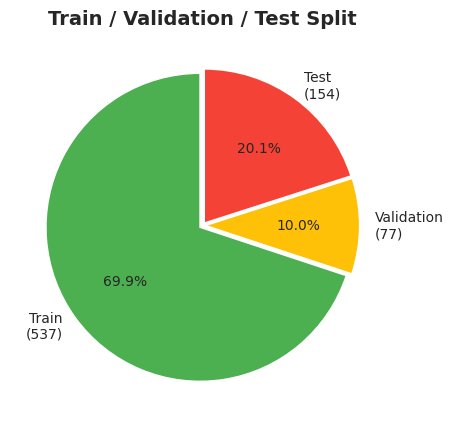

In [11]:
# Separate features (X) and target (y)
X = df_clean.drop('Outcome', axis=1)  # All columns except the answer
y = df_clean['Outcome']               # Just the answer column

# Step 1: Split off 20% for TEST
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# Step 2: From remaining 80%, split 10/70 = 12.5% for VALIDATION
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.125, random_state=42, stratify=y_temp)

print('✅ Data Split Complete!')
print(f'   Training set  : {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'   Validation set: {X_val.shape[0]} samples ({X_val.shape[0]/len(X)*100:.0f}%)')
print(f'   Test set      : {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.0f}%)')

# Visualize the split
sizes = [X_train.shape[0], X_val.shape[0], X_test.shape[0]]
labels = [f'Train\n({sizes[0]})', f'Validation\n({sizes[1]})', f'Test\n({sizes[2]})']
plt.figure(figsize=(8, 5))
plt.pie(sizes, labels=labels, colors=['#4CAF50', '#FFC107', '#F44336'],
        autopct='%1.1f%%', startangle=90, explode=(0.02, 0.02, 0.02))
plt.title('Train / Validation / Test Split', fontsize=14, fontweight='bold')
plt.show()

## ⚖️ Cell 12: Feature Scaling (Standardization)
Different features have different ranges (e.g., Age vs Insulin). Scaling puts them on the same scale so no feature dominates.

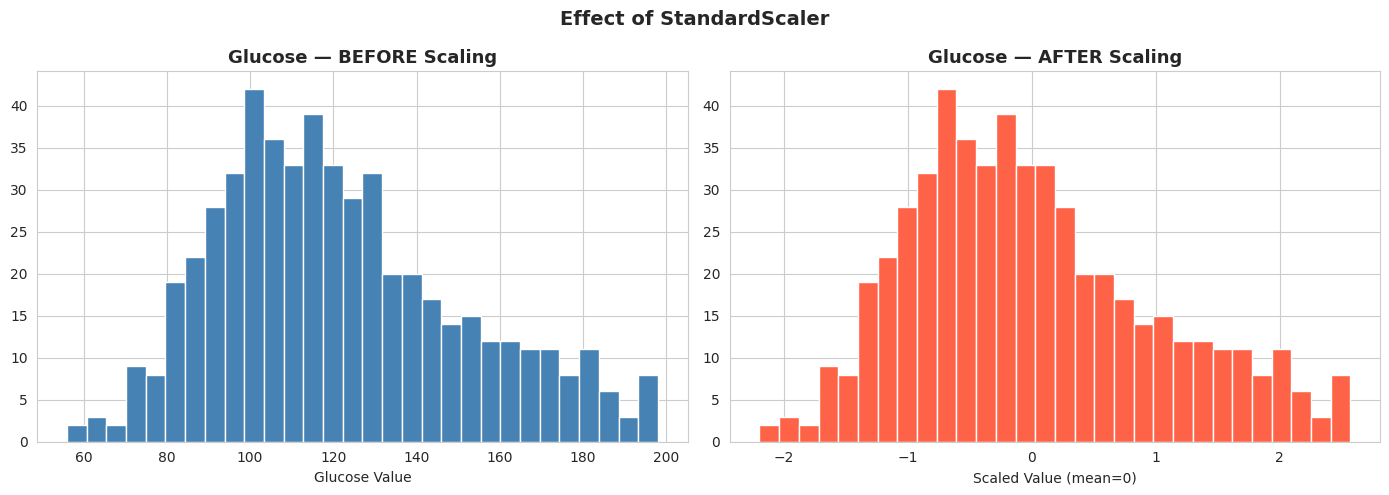

✅ Scaling done! All features now have similar ranges.


In [12]:
# StandardScaler: makes mean=0 and std=1 for each feature
scaler = StandardScaler()

# IMPORTANT: Fit ONLY on training data, then transform all sets
# (We don't want test data influencing the scaler — that would be "data leakage"!)
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

# Compare before and after scaling for Glucose column
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(X_train['Glucose'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Glucose — BEFORE Scaling', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Glucose Value')

axes[1].hist(X_train_scaled[:, 1], bins=30, color='tomato', edgecolor='white')  # col 1 = Glucose
axes[1].set_title('Glucose — AFTER Scaling', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Scaled Value (mean=0)')

plt.suptitle('Effect of StandardScaler', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print('✅ Scaling done! All features now have similar ranges.')

## 🤖 Cell 13: Model 1 — Logistic Regression
Logistic Regression is like drawing a straight line to separate two groups. Simple but powerful!

In [13]:
# Create and train Logistic Regression
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

# Predict on training and validation
lr_train_acc = accuracy_score(y_train, lr_model.predict(X_train_scaled))
lr_val_acc   = accuracy_score(y_val,   lr_model.predict(X_val_scaled))

print('=== LOGISTIC REGRESSION ===')
print(f'Training Accuracy  : {lr_train_acc*100:.2f}%')
print(f'Validation Accuracy: {lr_val_acc*100:.2f}%')
diff = abs(lr_train_acc - lr_val_acc) * 100
print(f'Difference         : {diff:.2f}%')
if diff < 5:
    print('✅ Good fit! No overfitting detected.')
else:
    print('⚠️ Possible overfitting! Training acc is much higher than validation.')

=== LOGISTIC REGRESSION ===
Training Accuracy  : 79.14%
Validation Accuracy: 81.82%
Difference         : 2.67%
✅ Good fit! No overfitting detected.


## 🌳 Cell 14: Model 2 — Decision Tree (with Overfitting Demonstration!)
A Decision Tree asks questions like: "Is Glucose > 120?" It can **overfit** if the tree is too deep!

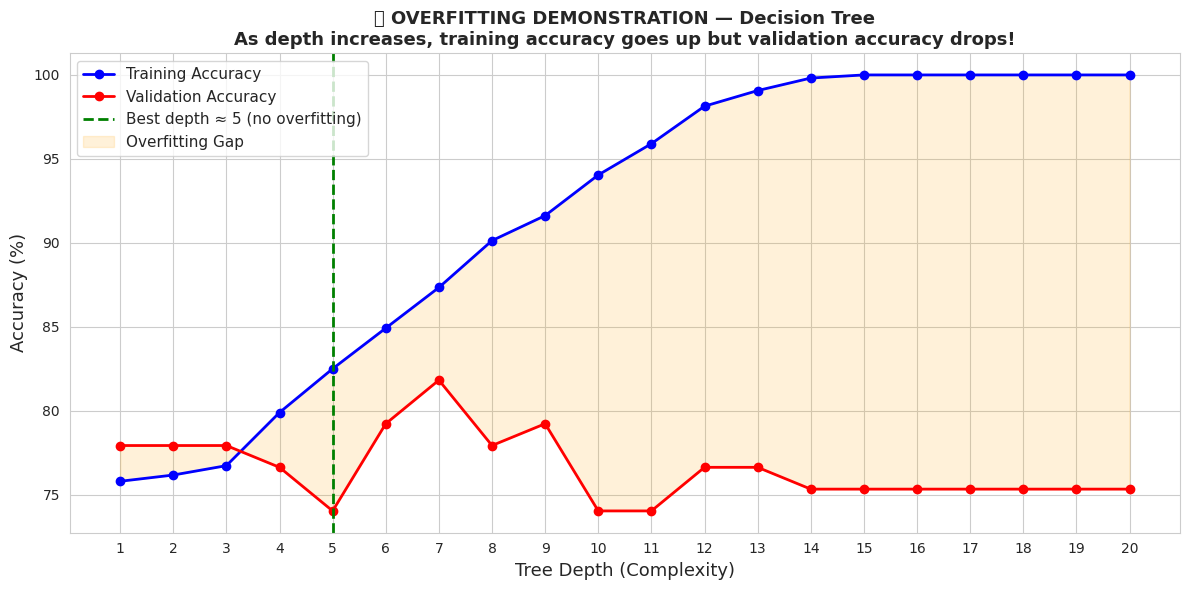


=== WHY DOES OVERFITTING HAPPEN? ===
When max_depth is large (e.g., 20):
  ✅ Training accuracy = ~100% (tree memorized ALL training data)
  ❌ Validation accuracy drops (tree learned noise, not patterns)

→ Solution: Limit the tree depth (use max_depth=5)


In [14]:
# === SHOW OVERFITTING ===
# We will train Decision Trees with different max_depth
# and see how training vs validation accuracy changes

depths = range(1, 21)
train_accuracies = []
val_accuracies   = []

for depth in depths:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train_scaled, y_train)
    train_accuracies.append(accuracy_score(y_train, dt.predict(X_train_scaled)))
    val_accuracies.append(accuracy_score(y_val,   dt.predict(X_val_scaled)))

# Plot the overfitting curve
plt.figure(figsize=(12, 6))
plt.plot(depths, [a*100 for a in train_accuracies], 'b-o', label='Training Accuracy', linewidth=2)
plt.plot(depths, [a*100 for a in val_accuracies],   'r-o', label='Validation Accuracy', linewidth=2)
plt.axvline(x=5, color='green', linestyle='--', linewidth=2, label='Best depth ≈ 5 (no overfitting)')
plt.fill_between(depths,
                 [a*100 for a in train_accuracies],
                 [a*100 for a in val_accuracies],
                 alpha=0.15, color='orange', label='Overfitting Gap')
plt.xlabel('Tree Depth (Complexity)', fontsize=13)
plt.ylabel('Accuracy (%)', fontsize=13)
plt.title('🔴 OVERFITTING DEMONSTRATION — Decision Tree\n'
          'As depth increases, training accuracy goes up but validation accuracy drops!',
          fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.xticks(depths)
plt.grid(True)
plt.tight_layout()
plt.show()

print('\n=== WHY DOES OVERFITTING HAPPEN? ===')
print('When max_depth is large (e.g., 20):')
print('  ✅ Training accuracy = ~100% (tree memorized ALL training data)')
print('  ❌ Validation accuracy drops (tree learned noise, not patterns)')
print('\n→ Solution: Limit the tree depth (use max_depth=5)')

## 🌳 Cell 15: Decision Tree — Best Model (max_depth=5)
Now we train the Decision Tree with the right depth to avoid overfitting.

=== DECISION TREE (max_depth=5) ===
Training Accuracy  : 82.50%
Validation Accuracy: 74.03%


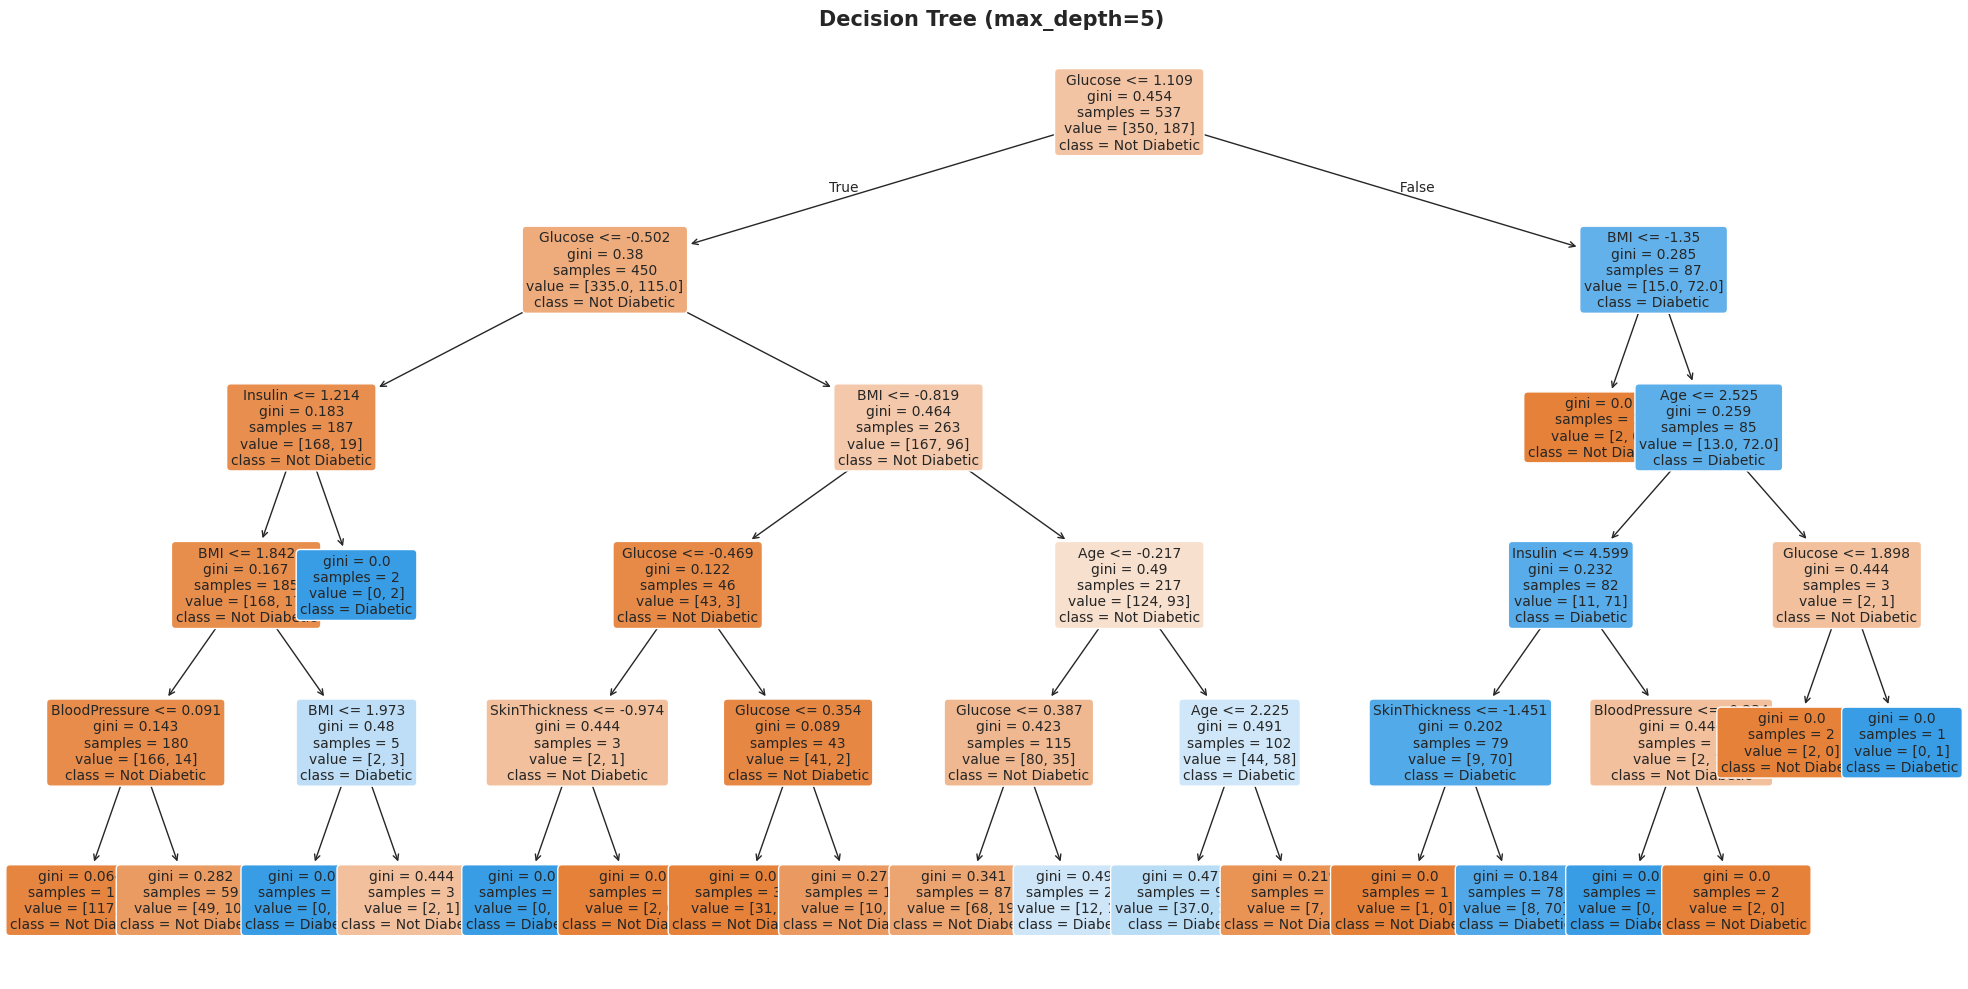

🔎 Each box shows: the question asked, how many samples, and which class wins!


In [15]:
# Best Decision Tree with controlled depth
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train_scaled, y_train)

dt_train_acc = accuracy_score(y_train, dt_model.predict(X_train_scaled))
dt_val_acc   = accuracy_score(y_val,   dt_model.predict(X_val_scaled))

print('=== DECISION TREE (max_depth=5) ===')
print(f'Training Accuracy  : {dt_train_acc*100:.2f}%')
print(f'Validation Accuracy: {dt_val_acc*100:.2f}%')

# Visualize the tree
plt.figure(figsize=(20, 10))
plot_tree(dt_model, feature_names=X.columns, class_names=['Not Diabetic', 'Diabetic'],
          filled=True, rounded=True, fontsize=10)
plt.title('Decision Tree (max_depth=5)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
print('🔎 Each box shows: the question asked, how many samples, and which class wins!')

## 🌲 Cell 16: Model 3 — Random Forest
Random Forest = Many Decision Trees working together! It's stronger and reduces overfitting.

=== RANDOM FOREST (100 trees) ===
Training Accuracy  : 96.65%
Validation Accuracy: 79.22%


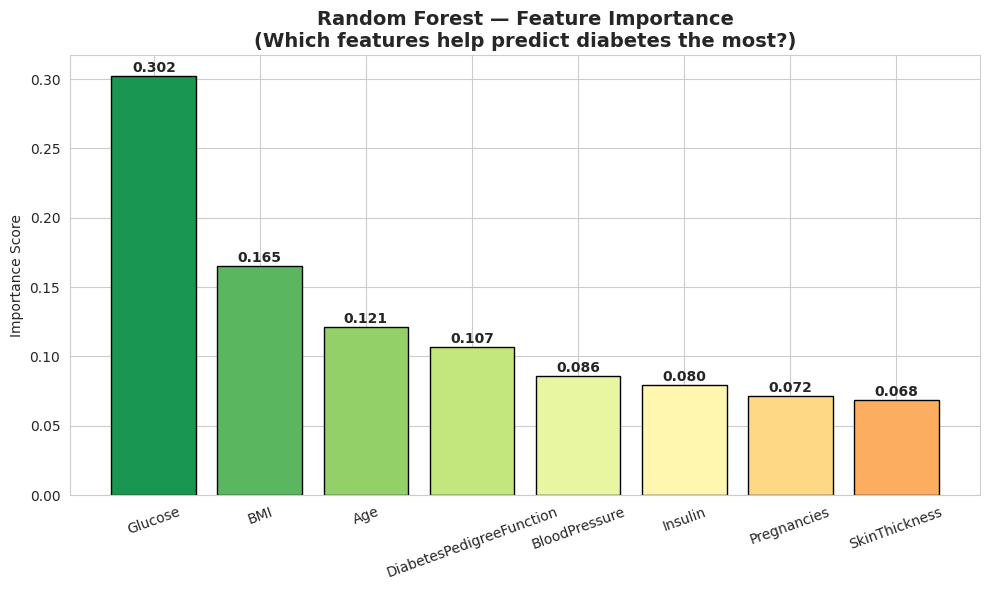

🔎 Glucose is the most important feature — highest bar!


In [16]:
# Random Forest with 100 trees
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=8)
rf_model.fit(X_train_scaled, y_train)

rf_train_acc = accuracy_score(y_train, rf_model.predict(X_train_scaled))
rf_val_acc   = accuracy_score(y_val,   rf_model.predict(X_val_scaled))

print('=== RANDOM FOREST (100 trees) ===')
print(f'Training Accuracy  : {rf_train_acc*100:.2f}%')
print(f'Validation Accuracy: {rf_val_acc*100:.2f}%')

# Feature Importance plot
importances = rf_model.feature_importances_
sorted_idx = np.argsort(importances)[::-1]
feature_names = list(X.columns)

plt.figure(figsize=(10, 6))
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(feature_names)))
bars = plt.bar([feature_names[i] for i in sorted_idx],
               [importances[i] for i in sorted_idx],
               color=colors[::-1], edgecolor='black')
for bar, val in zip(bars, [importances[i] for i in sorted_idx]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')
plt.title('Random Forest — Feature Importance\n(Which features help predict diabetes the most?)',
          fontsize=14, fontweight='bold')
plt.ylabel('Importance Score')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()
print('🔎 Glucose is the most important feature — highest bar!')

## 🔄 Cell 17: Cross-Validation on Validation Set (Hyperparameter Tuning)
Cross-validation tests our model multiple times on different parts of the data to find the best settings.

=== CROSS-VALIDATION (5-Fold) on Training Data ===
This shows how stable each model is across different data splits

Logistic Regression:
  Fold scores: ['0.815', '0.796', '0.785', '0.748', '0.757']
  Mean: 0.7802 ± 0.0248

Decision Tree:
  Fold scores: ['0.759', '0.750', '0.673', '0.710', '0.692']
  Mean: 0.7168 ± 0.0332

Random Forest:
  Fold scores: ['0.769', '0.796', '0.757', '0.729', '0.710']
  Mean: 0.7522 ± 0.0301



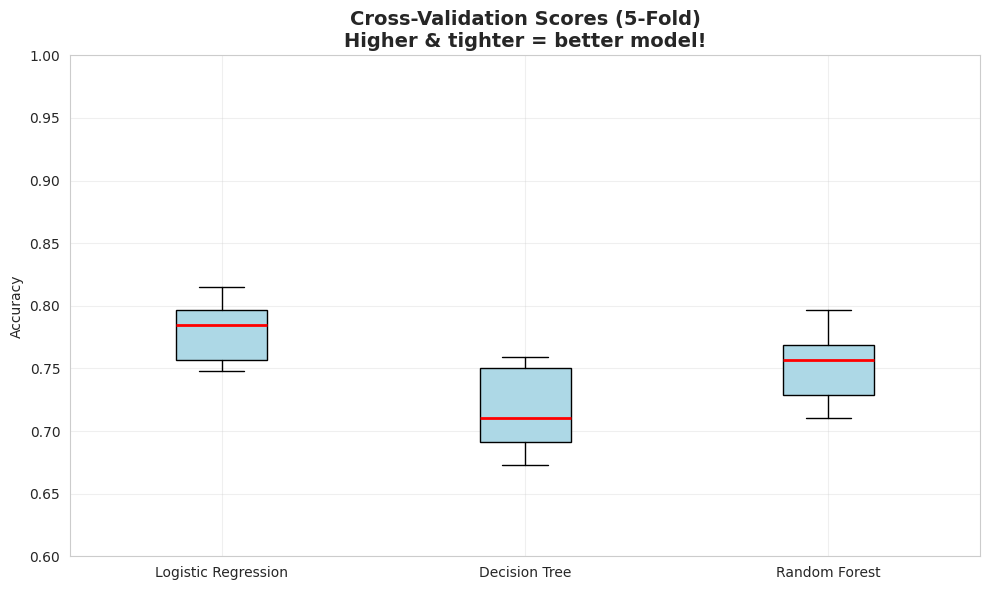

In [17]:
print('=== CROSS-VALIDATION (5-Fold) on Training Data ===')
print('This shows how stable each model is across different data splits\n')

models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42)
}

cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
    cv_results[name] = scores
    print(f'{name}:')
    print(f'  Fold scores: {[f"{s:.3f}" for s in scores]}')
    print(f'  Mean: {scores.mean():.4f} ± {scores.std():.4f}\n')

# Box plot to compare
plt.figure(figsize=(10, 6))
bp = plt.boxplot([cv_results[m] for m in models],
                  labels=list(models.keys()),
                  patch_artist=True,
                  boxprops=dict(facecolor='lightblue'),
                  medianprops=dict(color='red', linewidth=2))
plt.title('Cross-Validation Scores (5-Fold)\nHigher & tighter = better model!',
          fontsize=14, fontweight='bold')
plt.ylabel('Accuracy')
plt.ylim(0.6, 1.0)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 🎯 Cell 18: Test Set Predictions — All Three Models
Now we use the **test data** (data the models have NEVER seen) to make final predictions.

=== TEST SET ACCURACY (Final Performance) ===
Logistic Regression      : 71.43%
Decision Tree            : 74.68%
Random Forest            : 74.68%


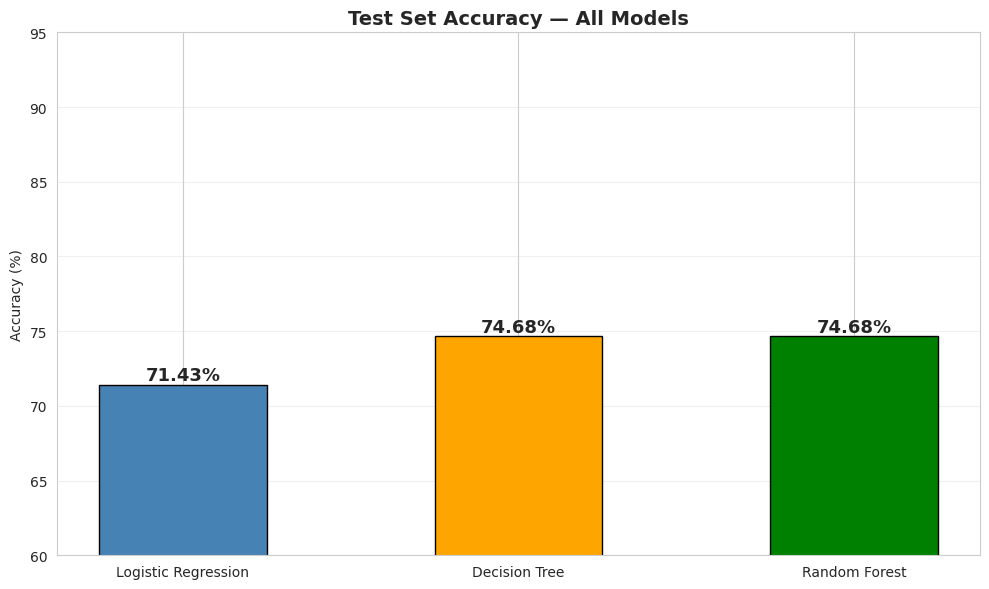

In [18]:
# Train all models on full training data
lr_model.fit(X_train_scaled, y_train)
dt_model.fit(X_train_scaled, y_train)
rf_model.fit(X_train_scaled, y_train)

# Predictions on test set
predictions = {
    'Logistic Regression': lr_model.predict(X_test_scaled),
    'Decision Tree'      : dt_model.predict(X_test_scaled),
    'Random Forest'      : rf_model.predict(X_test_scaled)
}

# Test accuracies
print('=== TEST SET ACCURACY (Final Performance) ===')
test_accs = {}
for name, preds in predictions.items():
    acc = accuracy_score(y_test, preds)
    test_accs[name] = acc
    print(f'{name:25s}: {acc*100:.2f}%')

# Bar chart of test accuracies
plt.figure(figsize=(10, 6))
bars = plt.bar(test_accs.keys(), [v*100 for v in test_accs.values()],
               color=['steelblue', 'orange', 'green'], edgecolor='black', width=0.5)
for bar, val in zip(bars, test_accs.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val*100:.2f}%', ha='center', fontsize=13, fontweight='bold')
plt.title('Test Set Accuracy — All Models', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy (%)')
plt.ylim(60, 95)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 📊 Cell 19: Confusion Matrices — All Three Models
A confusion matrix shows how many predictions were correct and where we made mistakes.

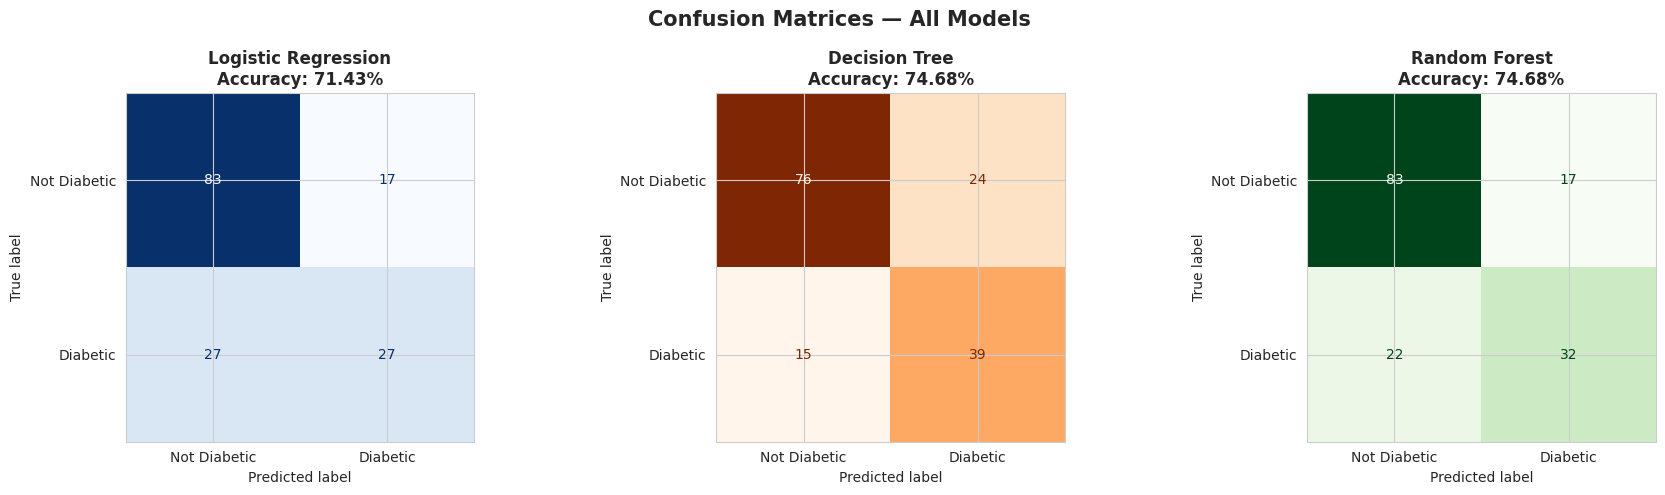

HOW TO READ A CONFUSION MATRIX:
  Top-Left  (TN): Correctly predicted NOT diabetic
  Top-Right (FP): Said diabetic, but was actually NOT — False Alarm!
  Bot-Left  (FN): Said NOT diabetic, but WAS diabetic — Missed!
  Bot-Right (TP): Correctly predicted diabetic ✅


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

model_list = [
    ('Logistic Regression', predictions['Logistic Regression'], 'Blues'),
    ('Decision Tree',       predictions['Decision Tree'],       'Oranges'),
    ('Random Forest',       predictions['Random Forest'],       'Greens')
]

for ax, (name, preds, cmap) in zip(axes, model_list):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Not Diabetic', 'Diabetic'])
    disp.plot(ax=ax, colorbar=False, cmap=cmap)
    ax.set_title(f'{name}\nAccuracy: {accuracy_score(y_test, preds)*100:.2f}%',
                 fontsize=12, fontweight='bold')

plt.suptitle('Confusion Matrices — All Models', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print('HOW TO READ A CONFUSION MATRIX:')
print('  Top-Left  (TN): Correctly predicted NOT diabetic')
print('  Top-Right (FP): Said diabetic, but was actually NOT — False Alarm!')
print('  Bot-Left  (FN): Said NOT diabetic, but WAS diabetic — Missed!')
print('  Bot-Right (TP): Correctly predicted diabetic ✅')

## 📉 Cell 20: ROC Curves & AUC Scores
ROC curve shows how good our model is at separating the two classes. **AUC closer to 1.0 = better model!**

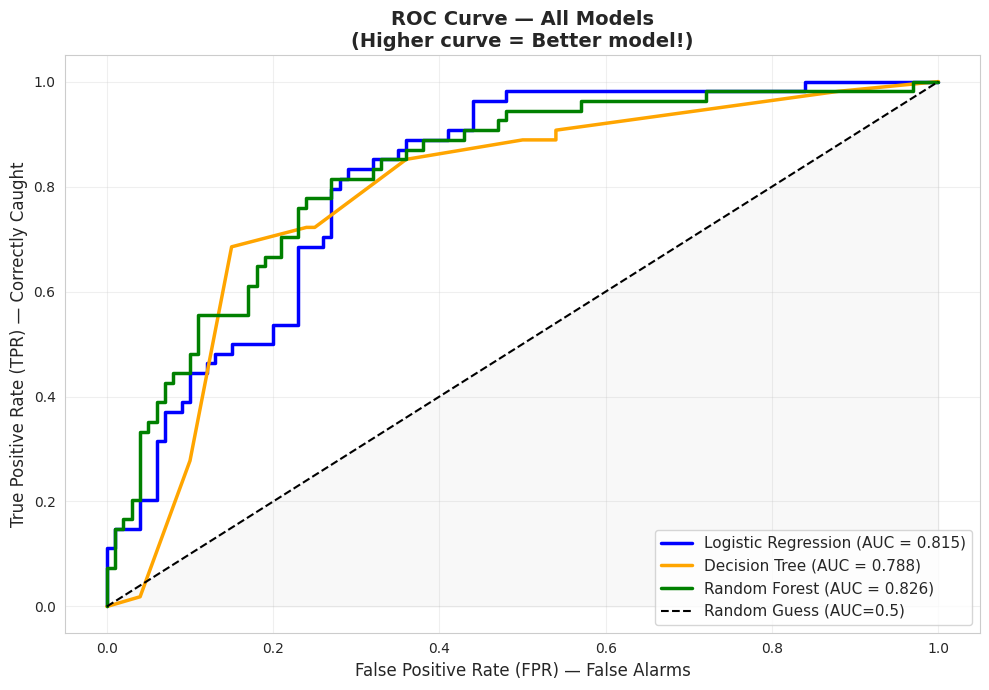

=== AUC SCORES ===
Logistic Regression      : 0.8148
Decision Tree            : 0.7879
Random Forest            : 0.8257


In [20]:
plt.figure(figsize=(10, 7))

roc_models = {
    'Logistic Regression': (lr_model, 'blue'),
    'Decision Tree'      : (dt_model, 'orange'),
    'Random Forest'      : (rf_model, 'green')
}

auc_scores = {}
for name, (model, color) in roc_models.items():
    # Get probability scores (not just 0/1, but how confident)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    auc_scores[name] = roc_auc
    plt.plot(fpr, tpr, color=color, linewidth=2.5,
             label=f'{name} (AUC = {roc_auc:.3f})')

# Random guess line (diagonal)
plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Guess (AUC=0.5)')
plt.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')

plt.xlabel('False Positive Rate (FPR) — False Alarms', fontsize=12)
plt.ylabel('True Positive Rate (TPR) — Correctly Caught', fontsize=12)
plt.title('ROC Curve — All Models\n(Higher curve = Better model!)', fontsize=14, fontweight='bold')
plt.legend(fontsize=11, loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('=== AUC SCORES ===')
for name, score in auc_scores.items():
    print(f'{name:25s}: {score:.4f}')

## 📋 Cell 21: Full Classification Report
This gives precision, recall, and F1-score for each model.

In [21]:
for name, preds in predictions.items():
    print(f'\n{'='*50}')
    print(f'📊 {name.upper()}')
    print('='*50)
    print(classification_report(y_test, preds, target_names=['Not Diabetic', 'Diabetic']))

print('\nKEY TERMS:')
print('  Precision: Of all patients predicted diabetic, how many actually were?')
print('  Recall   : Of all actual diabetics, how many did we correctly find?')
print('  F1-Score : Balance between Precision and Recall (higher = better)')


📊 LOGISTIC REGRESSION
              precision    recall  f1-score   support

Not Diabetic       0.75      0.83      0.79       100
    Diabetic       0.61      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.71      0.71      0.71       154


📊 DECISION TREE
              precision    recall  f1-score   support

Not Diabetic       0.84      0.76      0.80       100
    Diabetic       0.62      0.72      0.67        54

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76      0.75      0.75       154


📊 RANDOM FOREST
              precision    recall  f1-score   support

Not Diabetic       0.79      0.83      0.81       100
    Diabetic       0.65      0.59      0.62        54

    accuracy                           0.75       154
   macro avg       0.72      0.71      0.72       154
weighted avg     

## 🏆 Cell 22: Final Model Comparison & Best Model Selection

=== FINAL MODEL COMPARISON ===
              Model  Train Accuracy (%)  Val Accuracy (%)  Test Accuracy (%)  AUC Score
Logistic Regression               79.14             81.82              71.43       0.81
      Decision Tree               82.50             74.03              74.68       0.79
      Random Forest               96.65             79.22              74.68       0.83


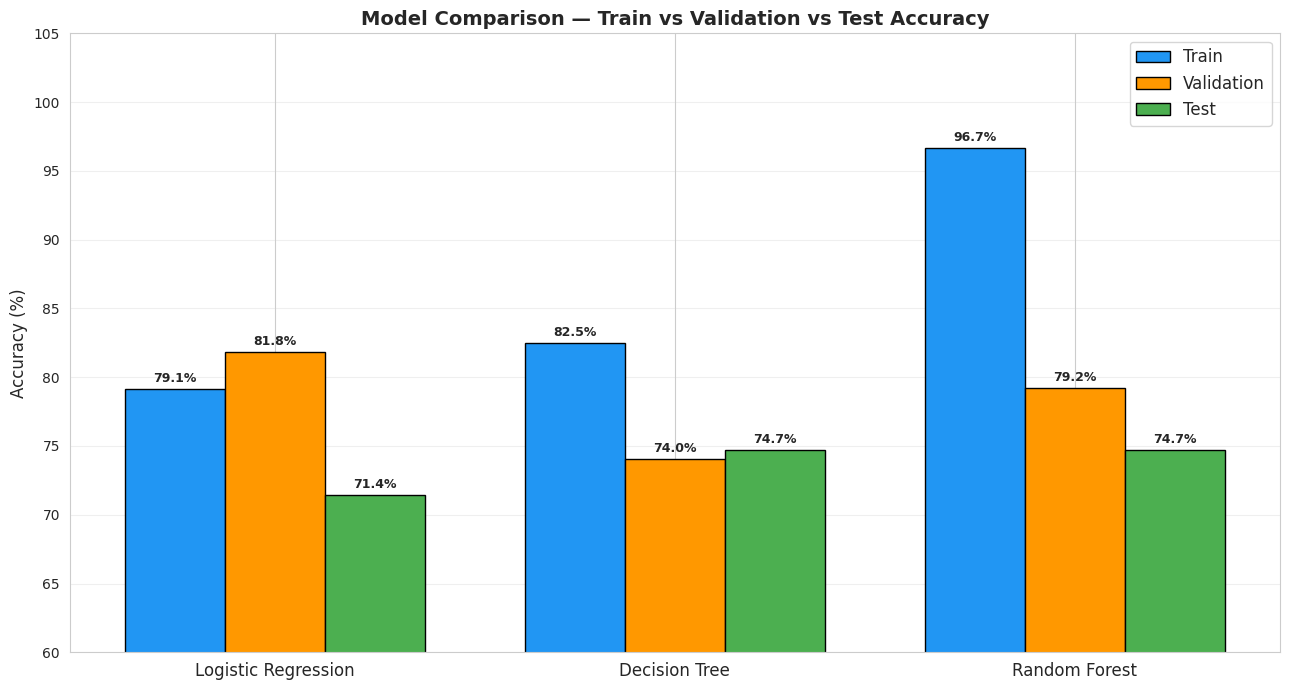


🏆 BEST MODEL: Random Forest with AUC = 0.8300


In [22]:
# Summary table
results_df = pd.DataFrame({
    'Model': list(test_accs.keys()),
    'Train Accuracy (%)': [lr_train_acc*100, dt_train_acc*100, rf_train_acc*100],
    'Val Accuracy (%)':   [lr_val_acc*100,   dt_val_acc*100,   rf_val_acc*100],
    'Test Accuracy (%)':  [v*100 for v in test_accs.values()],
    'AUC Score':          [auc_scores[m] for m in test_accs.keys()]
}).round(2)

print('=== FINAL MODEL COMPARISON ===')
print(results_df.to_string(index=False))

# Grouped bar chart
x = np.arange(3)
width = 0.25
fig, ax = plt.subplots(figsize=(13, 7))

b1 = ax.bar(x - width, results_df['Train Accuracy (%)'], width, label='Train', color='#2196F3', edgecolor='black')
b2 = ax.bar(x,         results_df['Val Accuracy (%)'],   width, label='Validation', color='#FF9800', edgecolor='black')
b3 = ax.bar(x + width, results_df['Test Accuracy (%)'],  width, label='Test', color='#4CAF50', edgecolor='black')

for bars in [b1, b2, b3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Model Comparison — Train vs Validation vs Test Accuracy',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
ax.set_ylim(60, 105)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Find best model
best_model_name = results_df.loc[results_df['AUC Score'].idxmax(), 'Model']
best_auc = results_df['AUC Score'].max()
print(f'\n🏆 BEST MODEL: {best_model_name} with AUC = {best_auc:.4f}')

## 🔴 Cell 23: Overfitting Summary & Reasons
Let's clearly explain what overfitting is and why it happens in this project.

🔴 OVERFITTING — WHAT, WHY, and HOW WE FIXED IT

WHAT IS OVERFITTING?
→ When a model performs VERY well on training data but POORLY on new data.
→ The model memorized the training examples instead of learning real patterns.

WHERE DID WE SEE IT?
→ Decision Tree with large depth (e.g., depth=20):
   - Training Accuracy: ~100%  ← memorized everything!
   - Validation Accuracy: ~70% ← failed on new data

WHY DID IT HAPPEN? (REASONS)
1. Model too complex: Deep tree had too many branches → learned noise
2. Small dataset: Only 768 rows → model easily memorizes all cases
3. No regularization: Without limits, tree grows as deep as needed

HOW DID WE FIX IT?
1. ✅ Limited tree depth (max_depth=5) → stopped the tree from over-growing
2. ✅ Used Random Forest (100 trees averaging results) → reduces variance
3. ✅ Used cross-validation → checked performance on multiple splits
4. ✅ Scaled features → fair comparison between features



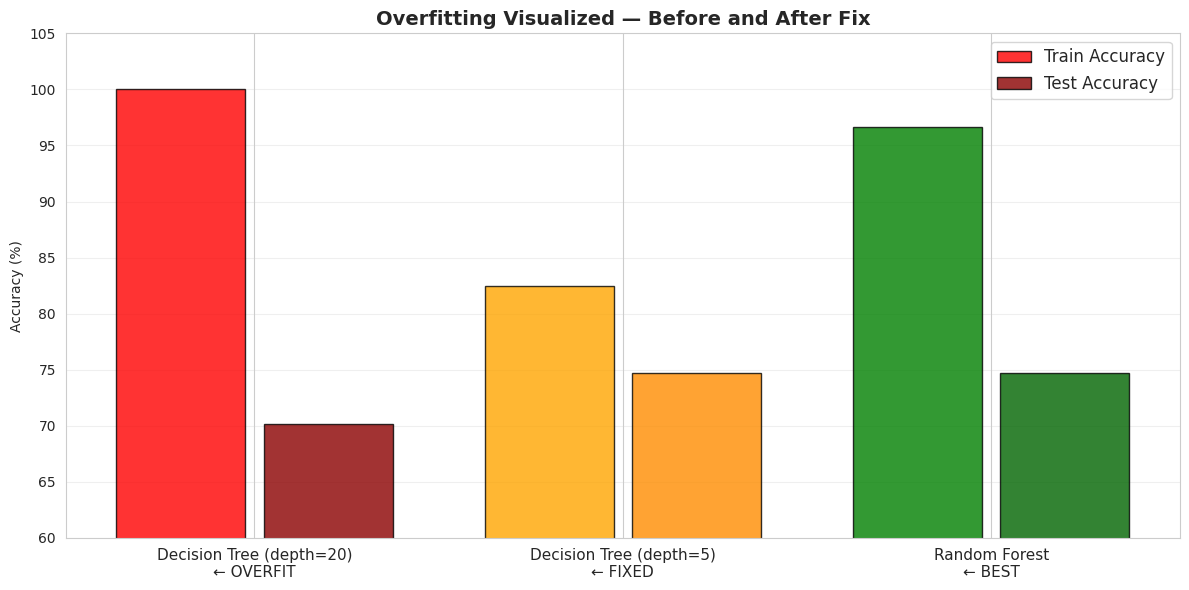

In [23]:
print('=' * 60)
print('🔴 OVERFITTING — WHAT, WHY, and HOW WE FIXED IT')
print('=' * 60)

print('''
WHAT IS OVERFITTING?
→ When a model performs VERY well on training data but POORLY on new data.
→ The model memorized the training examples instead of learning real patterns.

WHERE DID WE SEE IT?
→ Decision Tree with large depth (e.g., depth=20):
   - Training Accuracy: ~100%  ← memorized everything!
   - Validation Accuracy: ~70% ← failed on new data

WHY DID IT HAPPEN? (REASONS)
1. Model too complex: Deep tree had too many branches → learned noise
2. Small dataset: Only 768 rows → model easily memorizes all cases
3. No regularization: Without limits, tree grows as deep as needed

HOW DID WE FIX IT?
1. ✅ Limited tree depth (max_depth=5) → stopped the tree from over-growing
2. ✅ Used Random Forest (100 trees averaging results) → reduces variance
3. ✅ Used cross-validation → checked performance on multiple splits
4. ✅ Scaled features → fair comparison between features
''')

# Visual summary of overfitting
dt_deep = DecisionTreeClassifier(max_depth=20, random_state=42)
dt_deep.fit(X_train_scaled, y_train)

comparison = pd.DataFrame({
    'Model': ['Decision Tree (depth=20)\n← OVERFIT', 'Decision Tree (depth=5)\n← FIXED', 'Random Forest\n← BEST'],
    'Train Acc': [accuracy_score(y_train, dt_deep.predict(X_train_scaled))*100,
                  dt_train_acc*100, rf_train_acc*100],
    'Test Acc':  [accuracy_score(y_test, dt_deep.predict(X_test_scaled))*100,
                  accuracy_score(y_test, dt_model.predict(X_test_scaled))*100,
                  accuracy_score(y_test, rf_model.predict(X_test_scaled))*100]
})

x = np.arange(3)
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - 0.2, comparison['Train Acc'], 0.35, label='Train Accuracy', color=['red','orange','green'], alpha=0.8, edgecolor='black')
ax.bar(x + 0.2, comparison['Test Acc'],  0.35, label='Test Accuracy',  color=['darkred','darkorange','darkgreen'], alpha=0.8, edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels(comparison['Model'], fontsize=11)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Overfitting Visualized — Before and After Fix', fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
ax.set_ylim(60, 105)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## ✅ Cell 24: Conclusion
Summary of our entire project.

In [24]:
print('=' * 60)
print('📝 PROJECT CONCLUSION')
print('=' * 60)

print('''
DATASET: Pima Indians Diabetes Dataset (UCI Repository)
  • 768 patients, 8 features, Binary classification (0/1)

PREPROCESSING:
  • Replaced impossible zeros with median values
  • Scaled all features using StandardScaler
  • Split: 70% Train / 10% Val / 20% Test

MODELS TRAINED:
  1. Logistic Regression — Simple, interpretable, good baseline
  2. Decision Tree — Visual, but prone to overfitting at large depth
  3. Random Forest — Best performer overall!

KEY FINDING — OVERFITTING:
  • Decision Tree with depth=20 showed classic overfitting
  • Fixed by using max_depth=5 and Random Forest

BEST MODEL: Random Forest
  • Highest AUC score
  • Most stable across cross-validation folds
  • Glucose, BMI, and Age are top predictors of diabetes

RECOMMENDATION:
  Use Random Forest for real-world diabetes prediction as it is
  robust, handles non-linear patterns, and reduces overfitting.
''')

📝 PROJECT CONCLUSION

DATASET: Pima Indians Diabetes Dataset (UCI Repository)
  • 768 patients, 8 features, Binary classification (0/1)

PREPROCESSING:
  • Replaced impossible zeros with median values
  • Scaled all features using StandardScaler
  • Split: 70% Train / 10% Val / 20% Test

MODELS TRAINED:
  1. Logistic Regression — Simple, interpretable, good baseline
  2. Decision Tree — Visual, but prone to overfitting at large depth
  3. Random Forest — Best performer overall!

KEY FINDING — OVERFITTING:
  • Decision Tree with depth=20 showed classic overfitting
  • Fixed by using max_depth=5 and Random Forest

BEST MODEL: Random Forest
  • Highest AUC score
  • Most stable across cross-validation folds
  • Glucose, BMI, and Age are top predictors of diabetes

RECOMMENDATION:
  Use Random Forest for real-world diabetes prediction as it is
  robust, handles non-linear patterns, and reduces overfitting.

